In [2]:
from os.path import join
import numpy as np
import matplotlib.pyplot as plt

def load_data(load_dir, bid):
    SIZE = 512
    u = np.zeros((SIZE + 2, SIZE + 2))
    u[1:-1, 1:-1] = np.load(join(load_dir, f"{bid}_domain.npy"))
    interior_mask = np.load(join(load_dir, f"{bid}_interior.npy"))
    return u, interior_mask


def jacobi(u, interior_mask, max_iter, atol=1e-6):
    u = np.copy(u)

    for i in range(max_iter):
        # Compute average of left, right, up and down neighbors, see eq. (1)
        u_new = 0.25 * (u[1:-1, :-2] + u[1:-1, 2:] + u[:-2, 1:-1] + u[2:, 1:-1])
        u_new_interior = u_new[interior_mask]
        delta = np.abs(u[1:-1, 1:-1][interior_mask] - u_new_interior).max()
        u[1:-1, 1:-1][interior_mask] = u_new_interior

        if delta < atol:
            break
    return u


def summary_stats(u, interior_mask):
    u_interior = u[1:-1, 1:-1][interior_mask]
    mean_temp = u_interior.mean()
    std_temp = u_interior.std()
    pct_above_18 = np.sum(u_interior > 18) / u_interior.size * 100
    pct_below_15 = np.sum(u_interior < 15) / u_interior.size * 100
    return {
        'mean_temp': mean_temp,
        'std_temp': std_temp,
        'pct_above_18': pct_above_18,
        'pct_below_15': pct_below_15,
    }

# Task 1

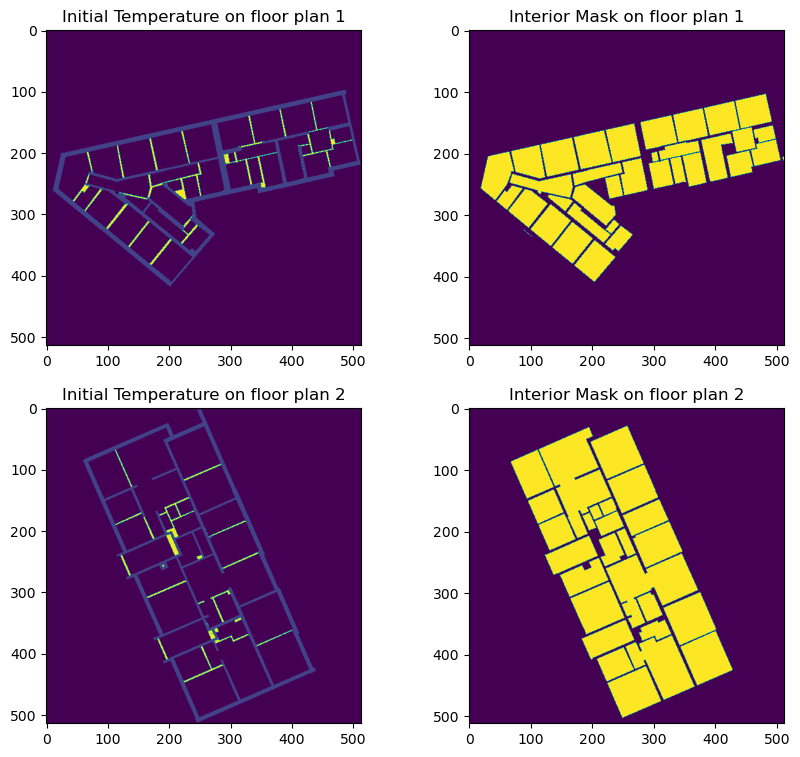

In [8]:
# Load data
LOAD_DIR = '/dtu/projects/02613_2025/data/modified_swiss_dwellings/'
with open(join(LOAD_DIR, 'building_ids.txt'), 'r') as f:
    building_ids = f.read().splitlines()
N = 2
building_ids = building_ids[:N]

# Load floor plans
all_u0 = np.empty((N, 514, 514))
all_interior_mask = np.empty((N, 512, 512), dtype='bool')
for i, bid in enumerate(building_ids):
    u0, interior_mask = load_data(LOAD_DIR, bid)
    all_u0[i] = u0
    all_interior_mask[i] = interior_mask

fig, ax = plt.subplots(N, 2, figsize=(10, 9), squeeze=False)
for i in range(N):
    ax[i, 0].imshow(all_u0[i])
    ax[i, 0].set_title(f'Initial Temperature on floor plan {i+1}')
    ax[i, 1].imshow(all_interior_mask[i])
    ax[i, 1].set_title(f'Interior Mask on floor plan {i+1}')


# Task 2

```
#!/bin/sh 
### General options 
### -- specify queue -- 
#BSUB -q hpc
### -- set the job Name -- 
#BSUB -J miniproject_job
### -- ask for number of cores (default: 1) -- 
#BSUB -n 1
### -- specify that the cores must be on the same host -- 
#BSUB -R "span[hosts=1]"
### -- specify that we need 4GB of memory per core/slot -- 
#BSUB -R "rusage[mem=5GB]"
#BSUB -R "select[model==XeonGold6126]"
### -- set walltime limit: hh:mm -- 
#BSUB -W 15
### -- send notification at start -- 
#BSUB -B 
### -- send notification at completion -- 
#BSUB -N 
### -- Specify the output and error file. %J is the job-id -- 
### -- -o and -e mean append, -oo and -eo mean overwrite -- 
#BSUB -o Output_%J.out 
#BSUB -e Output_%J.err 

# here follow the commands you want to execute with input.in as the input file
source /dtu/projects/02613_2025/conda/conda_init.sh

conda activate 02613

export N=20
echo "Running simulation with N=$N floor plans"
time python3 simulate.py $N
```

Task 3

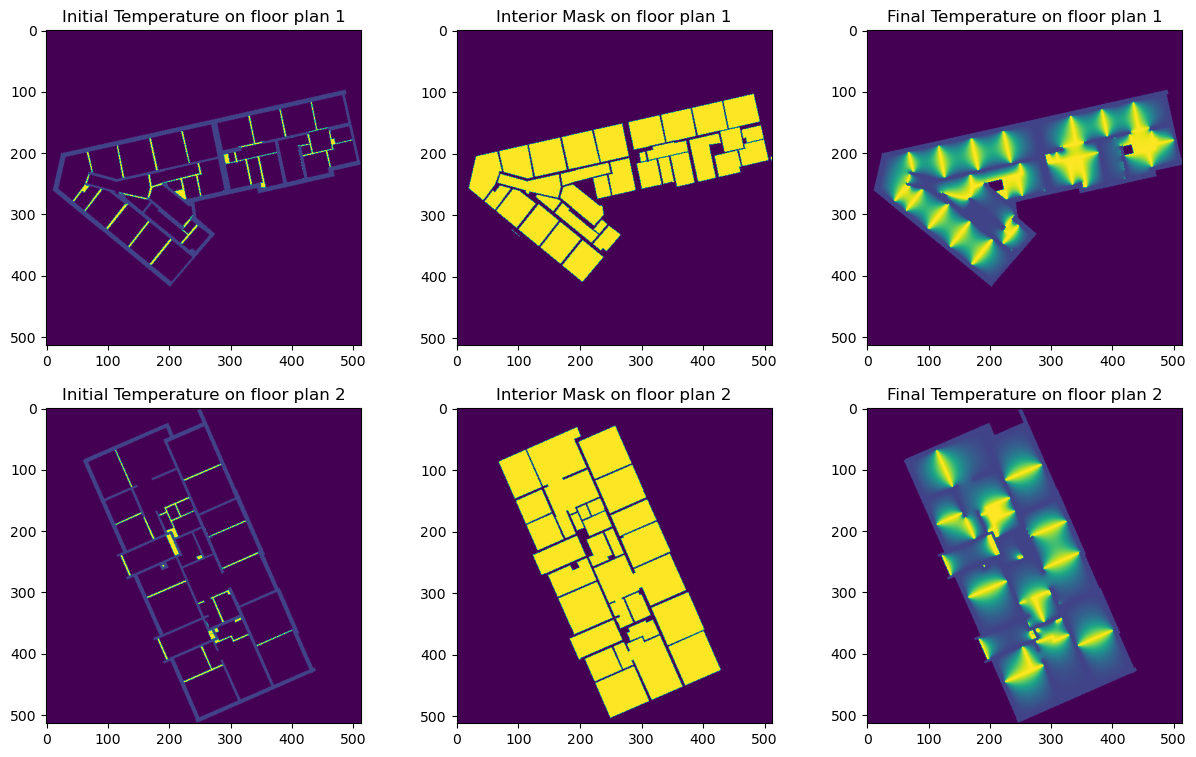

In [9]:
# Load data
all_u = np.empty((N, 514, 514))
for i, bid in enumerate(building_ids):
    all_u[i] = np.load(f'output/u{i}.npy')

fig, ax = plt.subplots(N, 3, figsize=(15, 9), squeeze=False)
for i in range(N):
    ax[i, 0].imshow(all_u0[i])
    ax[i, 0].set_title(f'Initial Temperature on floor plan {i+1}')
    ax[i, 1].imshow(all_interior_mask[i])
    ax[i, 1].set_title(f'Interior Mask on floor plan {i+1}')
    ax[i, 2].imshow(all_u[i])
    ax[i, 2].set_title(f'Final Temperature on floor plan {i+1}')


Task 4
```
n-62-27-20(s224375) $ python -m line_profiler -rmt "simulate.py.lprof"
Timer unit: 1e-06 s

Total time: 5.95895 s
File: simulate.py
Function: jacobi at line 15

Line #      Hits         Time  Per Hit   % Time  Line Contents
==============================================================
    15                                           @profile
    16                                           def jacobi(u, interior_mask, max_iter, atol=1e-6):
    17         1        714.2    714.2      0.0      u = np.copy(u)
    18                                           
    19      3602       1654.8      0.5      0.0      for i in range(max_iter):
    20                                                   # Compute average of left, right, up and down neighbors, see eq. (1)
    21      3602    3939150.6   1093.6     66.1          u_new = 0.25 * (u[1:-1, :-2] + u[1:-1, 2:] + u[:-2, 1:-1] + u[2:, 1:-1])
    22      3602     523715.9    145.4      8.8          u_new_interior = u_new[interior_mask]
    23      3602     935891.1    259.8     15.7          delta = np.abs(u[1:-1, 1:-1][interior_mask] - u_new_interior).max()
    24      3602     554706.7    154.0      9.3          u[1:-1, 1:-1][interior_mask] = u_new_interior
    25                                           
    26      3602       3117.4      0.9      0.1          if delta < atol:
    27         1          0.4      0.4      0.0              break
    28         1          0.2      0.2      0.0      return u

  5.96 seconds - simulate.py:15 - jacobi
```

In [ ]:
# Load data
LOAD_DIR = '/dtu/projects/02613_2025/data/modified_swiss_dwellings/'
with open(join(LOAD_DIR, 'building_ids.txt'), 'r') as f:
    building_ids = f.read().splitlines()
N = 1
building_ids = building_ids[:N]

# Load floor plans
all_u0 = np.empty((N, 514, 514))
all_interior_mask = np.empty((N, 512, 512), dtype='bool')
for i, bid in enumerate(building_ids):
    u0, interior_mask = load_data(LOAD_DIR, bid)
    all_u0[i] = u0
    all_interior_mask[i] = interior_mask

# Run jacobi iterations for each floor plan
MAX_ITER = 20_000
ABS_TOL = 1e-4

all_u = np.empty_like(all_u0)
for i, (u0, interior_mask) in enumerate(zip(all_u0, all_interior_mask)):
    u = jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)
    all_u[i] = u

# Print summary statistics in CSV format
stat_keys = ['mean_temp', 'std_temp', 'pct_above_18', 'pct_below_15']
print('building_id, ' + ', '.join(stat_keys))  # CSV header
for bid, u, interior_mask in zip(building_ids, all_u, all_interior_mask):
    stats = summary_stats(u, interior_mask)
    print(f"{bid},", ", ".join(str(stats[k]) for k in stat_keys))